# Lesson175 · Zero-shot evaluation

Implement an information-access audit before trusting a model score. Complete three TODOs, then replay all2,106real saved contexts. No paid jobs or fresh model inference are launched.

Author evidence: native-context audit COMPLETE; six checkpoint evaluations NOT_RUN after temporal gate failure. Your mastery remains PENDING_WRITTEN_DEFENSE.

In [ ]:
# @colab-bootstrap
import importlib.util, subprocess, sys
needed=[name for name,module in [('numpy','numpy'),('ml_dtypes==0.5.3','ml_dtypes'),('einops','einops'),('torch','torch')] if importlib.util.find_spec(module) is None]
if needed: subprocess.check_call([sys.executable,'-m','pip','install',*needed])
import numpy as np
from pathlib import Path
import json


**One win:** decide whether an unseen-database result deserves its claimed “zero-shot” label, then audit the inputs before trusting its score. About 20 minutes; the notebook is a separate practice session.

[171: exclude the database](https://avistian.github.io/relational/lessons/0171-corpus-of-databases.html) → [172: encode cells](https://avistian.github.io/relational/lessons/0172-schema-tokenization.html) → [173: pretrain](https://avistian.github.io/relational/lessons/0173-multi-task-pretraining.html) → [174: adapt](https://avistian.github.io/relational/lessons/0174-fine-tuning-protocol.html) → **175: evaluate without target updates**.

Recall: what does L171 exclude when holding out a database? Does L174 head-only tuning change parameters?

## 1 · Freeze the weights, then ask what else can change

Lesson 174 compared ways to update a model using later F1 labels. Even its “freeze” arm trained the task heads. Its tasks and database were already familiar to the model. It therefore left a different question unanswered: **can a pretrained model predict on a database excluded from its training?**

We need a model that can read new schemas. L173's database-specific task heads do not provide that interface. Here we inspect the released **Relational Transformer, RT-v1**, which represents cells using their values, types and column/table names. The checkpoint named `pretrain_rel-f1_driver-dnf.pt` is released as having excluded F1 from gradient pretraining. That is the authors' provenance claim; replaying its weights cannot independently reconstruct its training history. [Primary paper §4.1–4.3](https://arxiv.org/html/2510.06377v1#S4), [release card](https://huggingface.co/stanford-star/rt-v1).

**Gradient pretraining** changes the model's parameters to reduce a training loss. **Checkpoint selection** chooses among saved parameter states. **Context labels** are answers included in the input at inference. These are three different ways information can influence a prediction.

The RT paper calls database-held-out inference zero-shot even though target-task validation selects the released checkpoint and historical labels may appear in the sampled relational context. Its claim is therefore more specific than “the model has never accessed target labels.” We retain the paper's terminology and state the access paths beside it. Do not substitute today's RT-J quickstart for the original RT-v1 experiment: the architectures and preprocessing differ. [RT-v1 branch](https://github.com/stanford-star/relational-transformer/tree/8d83590b5ae7fba9e40e8df463ed2dd9066ce5fb).

## 2 · Model architecture: where can an answer enter?

**Reading route.** Trace sample → encode → twelve relational blocks → probability. Attention forms a weighted mixture of permitted cell representations; an attention mask specifies which cells may exchange information. Multiple attention heads learn different mixtures in parallel. The feed-forward network transforms each resulting cell vector, and a residual connection adds an update to the existing vector. In the figure, RMSNorm rescales a vector by its root-mean-square magnitude, while SwiGLU names the gated nonlinear feed-forward update. You can follow the information-access audit without deriving those two internal operators.

<figure tabindex="0">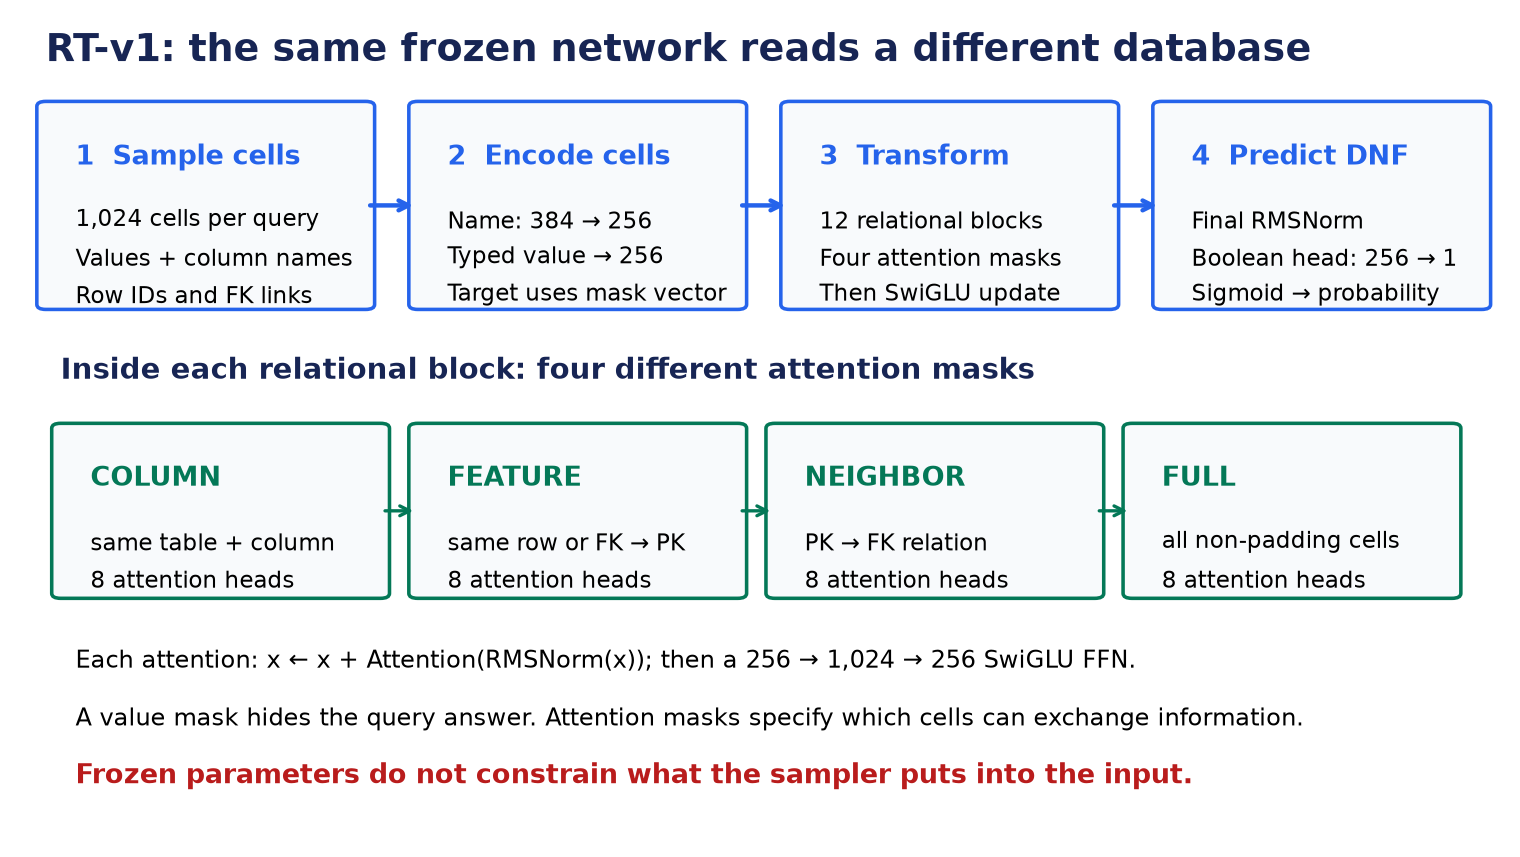<figcaption>Actual RT-v1 architecture: typed cell encoders, twelve four-attention blocks, and a frozen boolean head. The sampler determines information access. Scroll horizontally on narrow screens.</figcaption></figure>

A **cell token** is one field in one row. A typed linear encoder handles its value; a frozen language model supplies a 384-number description of its column and table name. RT projects both into 256-number representations. For the query target, a learned mask vector replaces the value representation. Its original label remains available to the scoring code, but must not enter the predictive representation.

A **foreign key (FK)** points from a child row to a parent's **primary key (PK)**. Each of twelve blocks applies column, feature, neighbor and full attention, then a feed-forward update. Column attention connects matching columns; feature attention connects the same row and FK→PK parents; neighbor attention uses the reverse relation; full attention connects all non-padding tokens. Residual additions preserve the previous representation. The boolean output head maps the final query representation to one logit, an unconstrained score; sigmoid converts it to a probability. [Source forward pass](https://avistian.github.io/relational/labs/sources/l175/upstream/rt/model.py).

We freeze the complete network, including every output head. **Input selection still matters:** if the sampler includes information unavailable at prediction time, a frozen model can exploit it.

## 3 · Write an information-access contract

Before computing a metric, record four questions:

| Access path | Released pretrain checkpoint | Released fine-tuned comparator |
|---|---|---|
| Target-database gradient updates | Excluded according to release | Included |
| Target-task validation selection | Used | Used |
| Historical labels in context | Permitted by sampler | Permitted by sampler |
| Query answer or unavailable information | Must be excluded for a clean claim | Must be excluded for a clean claim |

Predict how the claim changes when you toggle each access path. The fixed baseline stays visible.

Trace each access path: gradients, validation selection, historical context labels, unavailable answers. Frozen weights only close the first path.

A historical row from the test period is not automatically a leaked answer. Under a declared rolling evaluation, an earlier outcome may have become observable before a later query. A fixed offline test-label embargo would forbid that access. **Choose and report the policy; do not mix them.** Our audit records both test-period label access and whether each outcome window has finished.

## 4 · A row timestamp is not when its label becomes available

The F1 task asks whether a driver fails to finish a race in the following 30 days. A task row dated day 0 describes the prediction opportunity at day 0; its answer summarizes `(day 0, day 30]`. That answer cannot be assumed known on day 0. Even an earlier task row dated day −10 has an unfinished outcome window until day 20. [Exact task SQL](https://avistian.github.io/relational/labs/sources/l175/relbench-f1-task.py).

Predict first: does freezing weights make a same-time neighboring 30-day outcome safe? Explain before reading the answer.

<figure tabindex="0">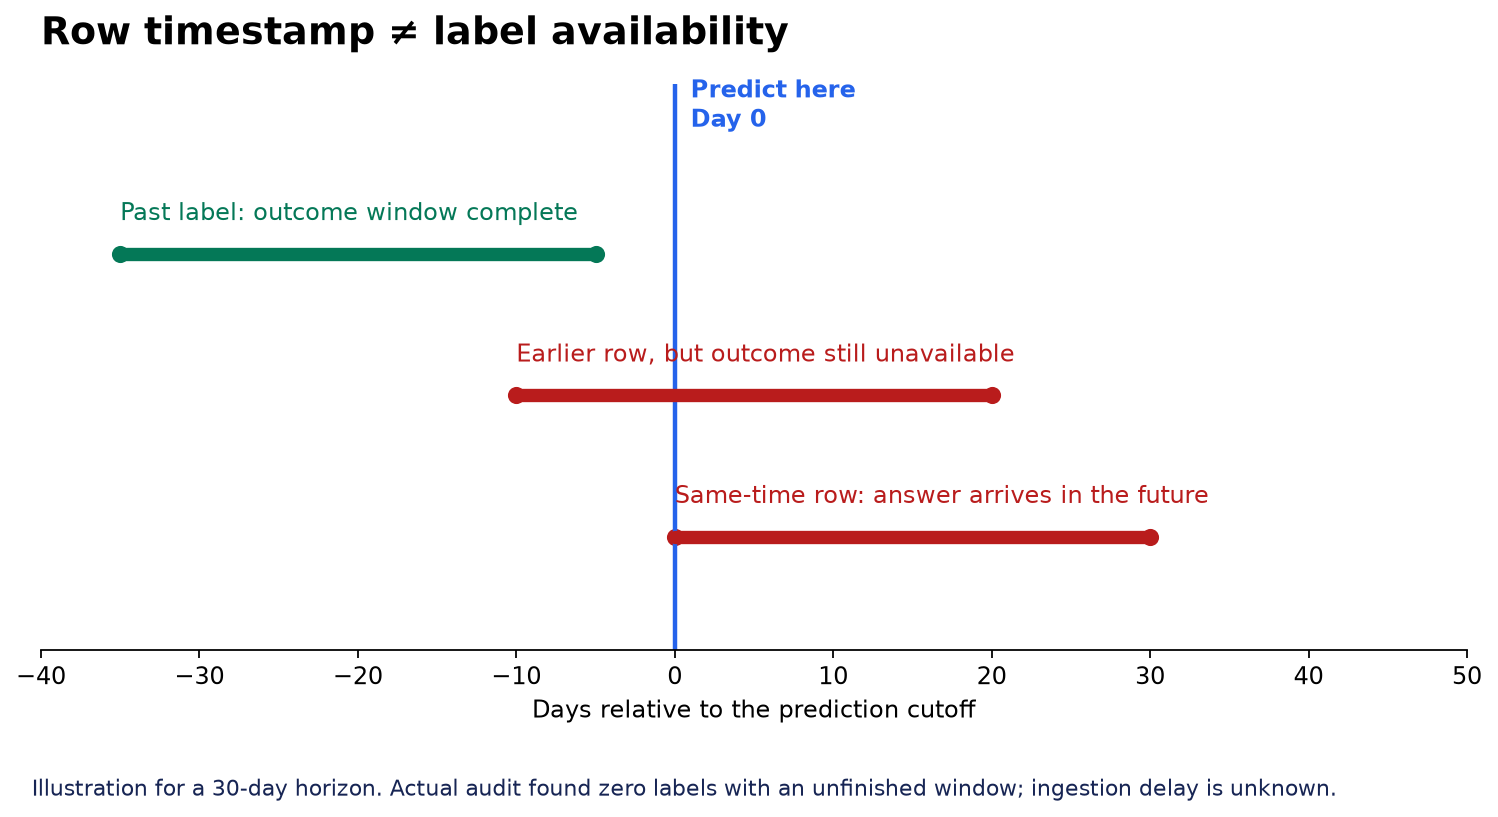<figcaption>Synthetic 30-day task illustration. A completed outcome window is necessary, but does not establish ingestion time. No unfinished-window labels were observed in the measured contexts. Scroll horizontally on narrow screens.</figcaption></figure>

For this task, a necessary outcome-availability condition is `label_cutoff + 30 days <= query_cutoff`. It does not prove immediate ingestion or the availability of every feature. Keep **event time** (when an event happens), **label horizon end** (when the target window finishes) and **arrival time** (when the system receives the information) separate.

The original sampler filters future PK→FK edges, but follows FK→PK edges without the same check. It masks only the query target. These source rules motivate direct checks of every emitted context; a code concern is not itself a measured count. [Sampler](https://avistian.github.io/relational/labs/sources/l175/upstream/rustler/src/fly.rs).

## 5 · Execute the audit before the performance run

Our approved target was two released checkpoints × three context seeds × all 702 official test queries: six full evaluations. We first ran the original native sampler at **1,024 cells, BFS width 256**, with seeds 0/1/2. We preserved all 2,106 contexts and independently reconstructed the query labels from all 26,080 raw F1 results rows.

| Check | Complete measured result |
|---|---:|
| Contexts / cell slots | 2,106 / 2,156,544 |
| Independently reconstructed query labels | 2,106 |
| Exposed query targets | 0 |
| Same-time visible outcome labels | 0 |
| Visible labels with unfinished outcome windows | 0 |
| Future-dated cells / affected contexts | **385 / 77** |
| Visible historical label cells | 29,988 |
| Historical test-period label cells | 12,351 |
| Cells without a timestamp | 432,050 |
| Checkpoint evaluations | **0 of 6 — NOT_RUN** |

Counts include repeated cells across query contexts. They are not counts of unique database rows. Context seeds0/1/2 contain26/26/25affected queries respectively.

<figure tabindex="0">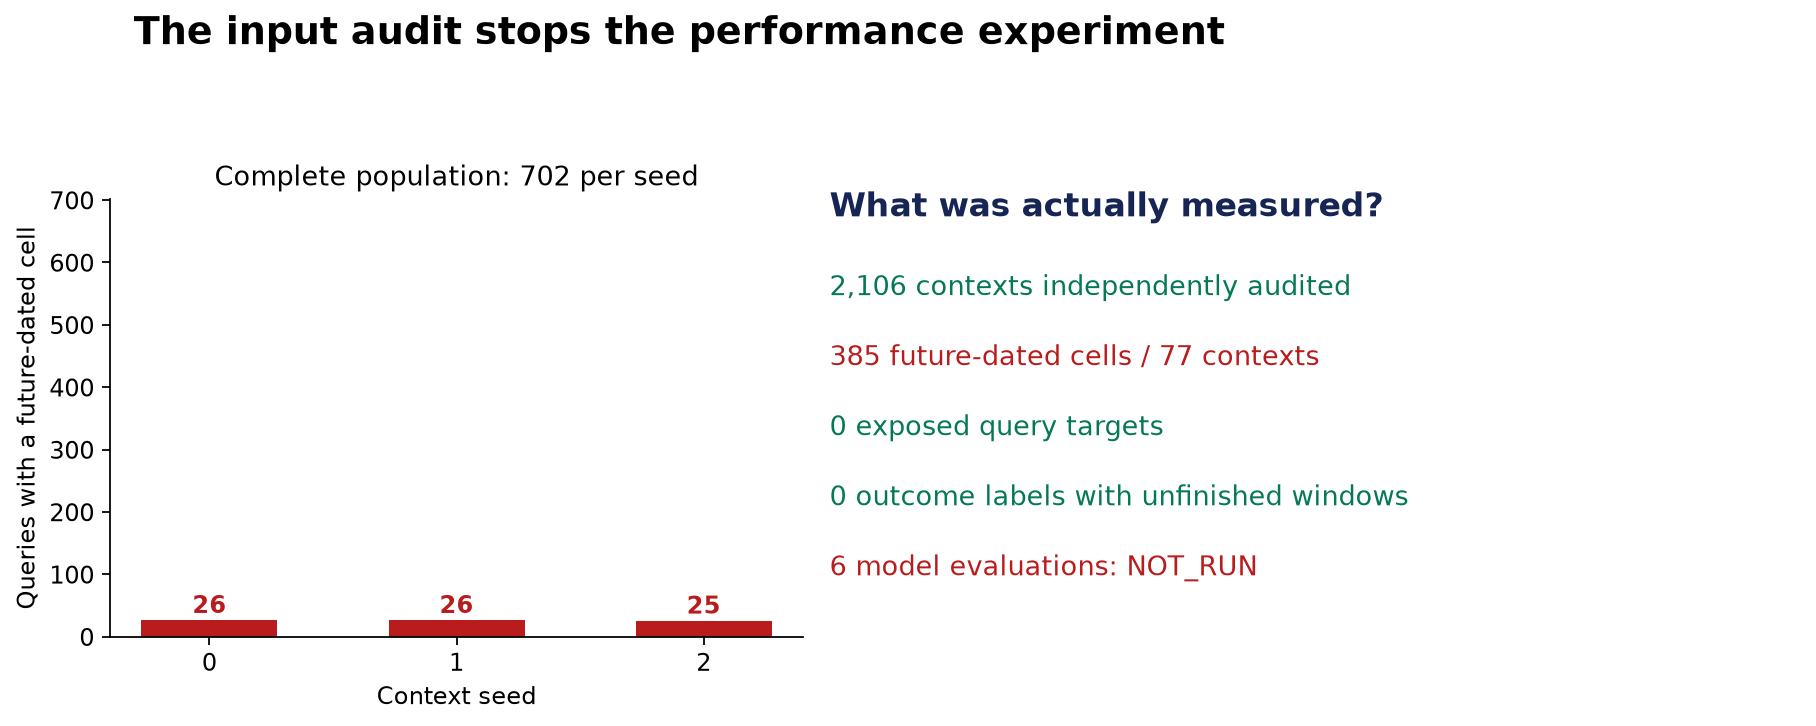<figcaption>Measured original-sampler audit: full702queries for each of three context seeds. Event-time audit fails; no model scores were computed. Scroll horizontally on narrow screens.</figcaption></figure>

All future-dated cells belong to **race schedule rows**: year, round, name, date and time. One query at **2011-03-27 00:00 UTC** includes a race dated **06:00 UTC** that day. The sampler reaches it through an unfiltered foreign-key-to-parent step. These attributes may have been known in advance; the snapshot contains no arrival history to prove that. We establish failure of the declared event-time filter, **not demonstrated exposure to future race outcomes**. The complete audit found no unmasked query target and no label with an unfinished outcome window.

The temporal contract fails before inference. **All six checkpoint evaluations remain `NOT_RUN`; there is no measured AUROC comparison.** We do not shrink the task, quietly fix the sampler, or treat a context audit as a model reproduction. The inference operator refuses the failed audit. Its post-gate GPU path is supplied but unvalidated because the gate blocked execution.

There is a second source limitation: the original preprocessing computes database-column statistics over the entire database table. Task validation/test numeric statistics are replaced with training-task statistics, but database columns and the global datetime statistics have a broader fit population. A source-faithful replay would retain that difference; a strict training-only reconstruction would be a separately named experiment. [Preprocessor](https://avistian.github.io/relational/labs/sources/l175/upstream/rustler/src/pre.rs).

<details><summary>Why not quote the paper's aggregate percentage as our result?</summary>

The curriculum's older summary mentions an aggregate percentage of supervised AUROC. Such a ratio averages a particular paper's task suite and version; it is not an accuracy percentage, a guaranteed ceiling, or a score for this F1 task. We did not reproduce that suite. The supplied fine-tuned comparator was released later and may not be the checkpoint behind the original table. The lesson therefore reports no numerical performance parity.

</details>

## 6 · Match complete identities before scoring

The same driver can appear at many cutoffs. The evaluation key is **(driver ID, cutoff)**. Matching only driver ID can overwrite predictions; matching row positions can silently compare the wrong answers after shuffling.

AUROC measures how often a positive example receives a higher score than a negative one, with half credit for a tie. For positive scores `[0.9, 0.7]` and negative scores `[0.2, 0.7]`, the four pairwise credits are `1, 1, 1, 0.5`, so AUROC is **0.875**. This is a synthetic arithmetic example, not a model result.

In the lab, first reject missing or duplicated complete keys. Then align the scores and compute the metric. A permuted prediction file should give the same answer; a missing cutoff should stop scoring. Three context seeds describe sampler variability on one database, not three independent replications across databases.

## 7 · Lab: defend the stop decision

[Open the prepared notebook](https://avistian.github.io/relational/labs/html/0175-zero-shot-evaluation.html) · [Download student notebook](https://avistian.github.io/relational/labs/0175-zero-shot-evaluation.ipynb) · [Reference solution](https://avistian.github.io/relational/labs/solutions/0175-zero-shot-evaluation.ipynb) · [Full reproduction contract](https://avistian.github.io/relational/labs/l175-reproduction.md).

Implement three live functions: classify information access, count unavailable context information, and align complete keys before AUROC. Immediate checks reject plausible wrong policies. Replay the complete saved sampler evidence; reconstruct all labels independently; inspect a future-dated witness. The notebook includes the original RT forward pass and full inference operator for inspection. It does not launch paid work.

**Exit:** write a short evaluation card stating the checkpoint's claimed training exclusion, validation access, context-label policy, exact failed check, and which numerical result you are still unable to claim. “The script ran” is not an evaluation defense.

Write your evaluation card before consulting teacher feedback.

Read **RT §4.1 and §4.3**, then compare its temporal promise to the sampler and preprocessor. [Primary reading](https://arxiv.org/html/2510.06377v1#S4). Keep the [quick reference](https://avistian.github.io/relational/reference/zero-shot-evaluation.html) beside your next experiment.

Next, L176 varies the number of labeled examples in context. Before studying that curve, we must specify which labels are allowed to be present. Ask the agent follow-up questions or paste your evaluation card for feedback; author preparation does not establish learner mastery.


## PROVIDED · Authenticate the complete portable evidence
The compressed bytes contain all contexts, original node metadata and raw F1 results used to reconstruct labels. Hashes catch accidental corruption. This is saved evidence, not output from a model trained in this kernel.

In [ ]:
import base64, hashlib, io, zipfile
PACKET='...'
EXPECTED={'contexts-0.npz': 'b46db81d6a4fd5ba3b1edeaf9b1571c5b1c931b609662f787a227e4e17382eaa', 'contexts-1.npz': '9a32caa3832a80330dd3eac7aaa1410c3857bf3ca6734f0e7d0e3defeb85e6a4', 'contexts-2.npz': 'a593cb36fc7acdbf81fe69a76aed886c121f7fa5575db924ddff3f1f1cdfc850', 'context-audit.json': '0ca3b7d9b8dae4580dee83329b50dc116bf2c8fd785f44c0ded7facfd023ca4e', 'label-oracle.npz': '2c53effcaefa40969b3e86c0b66761864e30bd38c1e7ae7740635c9a5a137b43', 'table_info.json': '059781e41efedf3715a965e5ce437dbdadf9aeb7fbd52024970dbc81f008ec16', 'column_index.json': '709341e7709991fb4999b7273889dc9a6d33e6dd3482fe72b2b25cf2337b0efd'}
root=Path('l175-packet');root.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(base64.b64decode(PACKET))) as z:
    assert set(z.namelist())==set(EXPECTED)
    for name,digest in EXPECTED.items():
        data=z.read(name);assert hashlib.sha256(data).hexdigest()==digest,name
        (root/name).write_bytes(data)
print('Authenticated',len(EXPECTED),'files. No network required for evidence.')

## TODO1 · Classify information access
Return the exact claim string. Unavailable answers take precedence; then target gradients; then validation/context labels. Freezing parameters alone is insufficient.

In [ ]:
def exposure_claim(target_gradients, target_validation, context_labels, test_exposure):
    raise NotImplementedError("TODO1 · Classify information access")

In [ ]:
assert exposure_claim(False,True,True,False)=='NO_TARGET_GRADIENTS_WITH_LABEL_ACCESS'
assert exposure_claim(False,False,False,True)=='INVALID_TEST_EXPOSURE'
print('CHECK1 passed: frozen weights are only one information boundary.')

## TODO2 · Audit available information
Timestamps are Unix seconds. Padding is excluded; unknown time is int32 minimum. Count each requested category, including labels whose outcome window has not finished. A known future schedule fails this strict event-time policy even when its real arrival time is unknown.

In [ ]:
def audit_context(timestamps,padding,query_targets,label_cells,masks,cutoff,horizon_seconds):
    raise NotImplementedError("TODO2 · Audit available information")

In [ ]:
probe=audit_context([0,0,-40,10],[False]*4,[True,False,False,False],[True,True,True,False],[True,False,False,False],0,30)
assert probe['unmasked_query_targets']==0 and probe['unavailable_labels']==1 and probe['future_cells']==1
print('CHECK2 passed: task-row time differs from outcome availability.')

## TODO3 · Align full identities, then score
Reject duplicate/missing (entity,cutoff) keys and nonfinite scores. Align scores to labels before computing pairwise AUROC. Give ties half credit. Do not collapse repeated entities.

In [ ]:
def aligned_auc(expected_keys, labels, prediction_keys, scores):
    raise NotImplementedError("TODO3 · Align full identities, then score")

In [ ]:
keys=np.array([[7,100],[7,200],[8,100],[8,200]]);y=np.array([0,1,1,0]);scores=np.array([.2,.9,.7,.7]);perm=[2,0,3,1]
assert aligned_auc(keys,y,keys[perm],scores[perm])==.875
print('CHECK3 passed: keyed synthetic AUROC is 0.875; this is not a model score.')

## PROVIDED / CHECK · Reject plausible wrong policies
The checks exercise your live functions, including missing keys, tie handling and unfinished outcome windows. Mutation checks temporarily substitute three wrong policies and must reject each.

In [ ]:
def reserve_cost(prior_upper_usd, seconds, rate, overhead_reserve=2., stop_usd=8.):
    """Reserve timeout plus 30s container overhead before each dispatch."""
    if seconds<=0 or rate<0 or any(x<0 for x in prior_upper_usd):raise ValueError('Invalid reservation')
    total=sum(prior_upper_usd)+(seconds+30)*rate+overhead_reserve
    if total>stop_usd:raise ValueError('INCOMPLETE_BUDGET_GATE')
    return total

In [ ]:
def checks():
 keys=np.array([[7,100],[7,200],[8,100],[8,200]])
 y=np.array([0,1,1,0]);p=np.array([.2,.9,.7,.7]);order=[2,0,3,1]
 assert aligned_auc(keys,y,keys[order],p[order])==.875
 for bad in [keys[:3],np.array([[7,100],[7,100],[8,100],[8,200]])]:
  try:aligned_auc(keys,y,bad,p[:len(bad)])
  except ValueError:pass
  else:raise AssertionError('missing or duplicate key accepted')
 assert exposure_claim(False,True,True,False)=='NO_TARGET_GRADIENTS_WITH_LABEL_ACCESS'
 assert exposure_claim(False,False,False,False)=='STRICT_NO_TARGET_LABEL_ACCESS'
 assert exposure_claim(True,False,False,False)=='TARGET_TRAINED'
 assert exposure_claim(False,False,False,True)=='INVALID_TEST_EXPOSURE'
 result=audit_context([100,100,90,110,-2147483648],[False,False,False,False,False],[True,False,False,False,False],[True,True,True,False,False],[True,False,False,False,False],100,30)
 assert result['unmasked_query_targets']==0
 assert result['same_time_labels']==1 and result['unavailable_labels']==2 and result['future_cells']==1
 assert reserve_cost([],600,.00028372,2,8)<8
 try:reserve_cost([6.5],600,.00028372,2,8)
 except ValueError:pass
 else:raise AssertionError('budget exceeded')
 return {'status':'PASS','contracts':['composite keys and tied AUROC','exposure axes','context availability','aggregate reservation']}

def mutation_checks():
    wrongs={'aligned_auc':lambda *a: .5,
            'exposure_claim':lambda *a: 'STRICT_NO_TARGET_LABEL_ACCESS',
            'audit_context':lambda *a: {'unmasked_query_targets':0,'same_time_labels':0,'unavailable_labels':0,'future_cells':0}}
    rejected=[]
    for name,wrong in wrongs.items():
        original=globals()[name];globals()[name]=wrong
        try:
            try:checks()
            except AssertionError:rejected.append(name)
            else:raise RuntimeError('Wrong learner implementation passed: '+name)
        finally:globals()[name]=original
    assert len(rejected)==3
    return rejected

In [ ]:
print(checks());print('Rejected wrong policies:',mutation_checks())

## PROVIDED · Full replay and independent label reconstruction
For each of702queries×3seeds, invoke your context audit, validate full identities, and independently derive DNF from raw race results in the following30days. Compare against the native-sampler receipt. This runs your TODO2 over every context, not a canned answer.

In [ ]:
def replay_packet(root, count_context):
    """Replay all saved contexts with the live learner policy and raw F1 oracle.

    No model inference, native sampling or paid work is performed here.
    """
    import json
    from pathlib import Path
    import ml_dtypes
    root=Path(root);ref=json.loads((root/'context-audit.json').read_text())
    meta=json.loads((root/'table_info.json').read_text());cols=json.loads((root/'column_index.json').read_text())
    raw=np.load(root/'label-oracle.npz');target_col=cols['did_not_finish of driver-dnf']
    records=[];identities=None
    for seed in range(3):
        data=np.load(root/f'contexts-{seed}.npz');assert data['node_idxs'].shape==(702,1024)
        keys=[];query_nodes=[]
        for i in range(702):
            target=data['is_targets'][i];assert target.sum()==1
            cutoff=int(data['timestamps'][i][target][0]);node=int(data['node_idxs'][i][target][0])
            parent=int(data['f2p_nbr_idxs'][i][target][0,0]);row=parent-meta['drivers:Db']['node_idx_offset']
            driver=int(raw['driver_ids'][row]);keys.append((driver,cutoff));query_nodes.append(node)
            value=data['boolean_values'][i][target].view(ml_dtypes.bfloat16).astype(float)[0]
            eligible=(raw['driver']==driver)&(raw['time']>cutoff)&(raw['time']<=cutoff+30*86400)
            assert eligible.any() and int(value>0)==int((raw['status'][eligible]!=1).any())
            result=count_context(data['timestamps'][i],data['is_padding'][i],target,data['col_name_idxs'][i]==target_col,data['masks'][i],cutoff,30*86400)
            expected=ref['records'][seed*702+i]
            assert all(result[k]==expected[k] for k in result),'Context audit differs from independent evidence'
            assert set(result)=={'unmasked_query_targets','same_time_labels','unavailable_labels','future_cells','unknown_time_cells','visible_label_cells'}
            records.append(result)
        assert len(set(keys))==702 and sorted(query_nodes)==list(range(97606,98308))
        if identities is None:identities=set(keys)
        assert set(keys)==identities
    totals={k:sum(r[k] for r in records) for k in records[0]}
    gate='BLOCKED_TEMPORAL_AUDIT' if any(totals[k] for k in ['unmasked_query_targets','unavailable_labels','future_cells']) else 'PASS'
    assert gate==ref['inference_gate']
    return dict(contexts=len(records),query_labels_reconstructed=len(records),totals=totals,inference_gate=gate,model_evaluations='NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')

In [ ]:
report=replay_packet(root,audit_context)
assert report['contexts']==2106
assert report['totals']['future_cells']==385
print(json.dumps(report,indent=2))
Path('l175-replay.json').write_text(json.dumps(report,indent=2))

## EXIT · Written evaluation card
Explain which database was excluded, who selected the checkpoint, which labels the context may expose, why the event-time check failed, and why future scheduled fields do not prove outcome leakage. State which model result remains unmeasured. Paste this defense to your teacher for feedback.

In [ ]:
submission={'learner':'PENDING_WRITTEN_DEFENSE','defense':''}
Path('l175-submission.json').write_text(json.dumps(submission,indent=2))
assert not submission['defense']  # Fill in your own explanation; no author answer is submitted.

## Appendix A · Original RT-v1 model, visible end to end
These are the archived source definitions used by the proposed reproduction. They are provided for inspection. Defining them does not load weights, reproduce training, or execute GPU inference. Follow name/value/mask encoding → attention masks →12blocks → boolean head. The main practice above concerns evaluation, so we do not replace this model with a toy.

In [ ]:
import json
import os
from functools import partial
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from einops import rearrange
from einops._torch_specific import allow_ops_in_compiled_graph
from ml_dtypes import bfloat16
from torch import nn
from torch.nn.attention import SDPBackend, sdpa_kernel
from torch.nn.attention.flex_attention import create_block_mask, flex_attention

allow_ops_in_compiled_graph()
flex_attention = torch.compile(flex_attention)



### MaskedAttention
Project Q/K/V, apply a relation-specific attention mask, then project back.

In [ ]:
class MaskedAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads

        self.wq = nn.Linear(d_model, d_model, bias=False)
        self.wk = nn.Linear(d_model, d_model, bias=False)
        self.wv = nn.Linear(d_model, d_model, bias=False)
        self.wo = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, block_mask):
        q = self.wq(x)
        k = self.wk(x)
        v = self.wv(x)

        q = rearrange(q, "b s (h d) -> b h s d", h=self.num_heads)
        k = rearrange(k, "b s (h d) -> b h s d", h=self.num_heads)
        v = rearrange(v, "b s (h d) -> b h s d", h=self.num_heads)

        if block_mask is None:
            with sdpa_kernel(SDPBackend.FLASH_ATTENTION):
                x = F.scaled_dot_product_attention(q, k, v)
        else:
            x = flex_attention(q, k, v, block_mask=block_mask)

        x = rearrange(x, "b h s d -> b s (h d)")
        x = self.wo(x)
        return x

### FFN
SwiGLU uses one branch to gate another before the return projection.

In [ ]:
class FFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()

        self.w1 = nn.Linear(d_model, d_ff, bias=False)
        self.w2 = nn.Linear(d_ff, d_model, bias=False)
        self.w3 = nn.Linear(d_model, d_ff, bias=False)

    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))

### RelationalBlock
Four residual attention stages followed by a residual feed-forward stage.

In [ ]:
class RelationalBlock(nn.Module):
    def __init__(
        self,
        d_model,
        num_heads,
        d_ff,
    ):
        super().__init__()

        self.norms = nn.ModuleDict(
            {l: nn.RMSNorm(d_model) for l in ["feat", "nbr", "col", "full", "ffn"]}
        )
        self.attns = nn.ModuleDict(
            {
                l: MaskedAttention(d_model, num_heads)
                for l in ["feat", "nbr", "col", "full"]
            }
        )
        self.ffn = FFN(d_model, d_ff)

    def forward(self, x, block_masks):
        for l in ["col", "feat", "nbr", "full"]:
            x = x + self.attns[l](self.norms[l](x), block_mask=block_masks[l])
        x = x + self.ffn(self.norms["ffn"](x))
        return x

### _make_block_mask
Convert explicit allowed cell pairs into the native attention representation.

In [ ]:
def _make_block_mask(mask, batch_size, seq_len, device):
    def _mod(b, h, q_idx, kv_idx):
        return mask[b, q_idx, kv_idx]

    return create_block_mask(
        mask_mod=_mod,
        B=batch_size,
        H=None,
        Q_LEN=seq_len,
        KV_LEN=seq_len,
        device=device,
        _compile=True,
    )

### RelationalTransformer
All semantic encoders, mask vectors, relation masks, twelve blocks, and typed heads. Label tensors enter the loss; masked label values are excluded from token encoding.

In [ ]:
class RelationalTransformer(nn.Module):
    def __init__(
        self,
        num_blocks,
        d_model,
        d_text,
        num_heads,
        d_ff,
    ):
        super().__init__()

        self.enc_dict = nn.ModuleDict(
            {
                "number": nn.Linear(1, d_model, bias=True),
                "text": nn.Linear(d_text, d_model, bias=True),
                "datetime": nn.Linear(1, d_model, bias=True),
                "col_name": nn.Linear(d_text, d_model, bias=True),
                "boolean": nn.Linear(1, d_model, bias=True),
            }
        )
        self.dec_dict = nn.ModuleDict(
            {
                "number": nn.Linear(d_model, 1, bias=True),
                "text": nn.Linear(d_model, d_text, bias=True),
                "datetime": nn.Linear(d_model, 1, bias=True),
                "boolean": nn.Linear(d_model, 1, bias=True),
            }
        )
        self.norm_dict = nn.ModuleDict(
            {
                "number": nn.RMSNorm(d_model),
                "text": nn.RMSNorm(d_model),
                "datetime": nn.RMSNorm(d_model),
                "col_name": nn.RMSNorm(d_model),
                "boolean": nn.RMSNorm(d_model),
            }
        )
        self.mask_embs = nn.ParameterDict(
            {
                t: nn.Parameter(torch.randn(d_model))
                for t in ["number", "text", "datetime", "boolean"]
            }
        )
        self.blocks = nn.ModuleList(
            [RelationalBlock(d_model, num_heads, d_ff) for i in range(num_blocks)]
        )
        self.norm_out = nn.RMSNorm(d_model)
        self.d_model = d_model

    def forward(self, batch):
        node_idxs = batch["node_idxs"]
        f2p_nbr_idxs = batch["f2p_nbr_idxs"]
        col_name_idxs = batch["col_name_idxs"]
        table_name_idxs = batch["table_name_idxs"]
        is_padding = batch["is_padding"]
        batch_size, seq_len = node_idxs.shape

        batch_size, seq_len = node_idxs.shape
        device = node_idxs.device

        # Padding mask for attention pairs (allow only non-pad -> non-pad)
        pad = (~is_padding[:, :, None]) & (~is_padding[:, None, :])  # (B, S, S)

        # cells in the same node
        same_node = node_idxs[:, :, None] == node_idxs[:, None, :]  # (B, S, S)

        # kv index is among q's foreign -> primary neighbors
        kv_in_f2p = (node_idxs[:, None, :, None] == f2p_nbr_idxs[:, :, None, :]).any(
            -1
        )  # (B, S, S)

        # q index is among kv's primary -> foreign neighbors (reverse relation)
        q_in_f2p = (node_idxs[:, :, None, None] == f2p_nbr_idxs[:, None, :, :]).any(
            -1
        )  # (B, S, S)

        # Same column AND same table
        same_col_table = (col_name_idxs[:, :, None] == col_name_idxs[:, None, :]) & (
            table_name_idxs[:, :, None] == table_name_idxs[:, None, :]
        )  # (B, S, S)

        # Final boolean masks (apply padding once here)
        attn_masks = {
            "feat": (same_node | kv_in_f2p) & pad,
            "nbr": q_in_f2p & pad,
            "col": same_col_table & pad,
            "full": pad,
        }

        # Make them contiguous for better kernel performance
        for l in attn_masks:
            attn_masks[l] = attn_masks[l].contiguous()

        # Convert to block masks
        make_block_mask = partial(
            _make_block_mask,
            batch_size=batch_size,
            seq_len=seq_len,
            device=device,
        )
        block_masks = {
            l: make_block_mask(attn_mask) for l, attn_mask in attn_masks.items()
        }

        x = 0
        x = x + (
            self.norm_dict["col_name"](
                self.enc_dict["col_name"](batch["col_name_values"])
            )
            * (~is_padding)[..., None]
        )

        for i, t in enumerate(["number", "text", "datetime", "boolean"]):
            x = x + (
                self.norm_dict[t](self.enc_dict[t](batch[t + "_values"]))
                * ((batch["sem_types"] == i) & ~batch["masks"] & ~is_padding)[..., None]
            )
            x = x + (
                self.mask_embs[t]
                * ((batch["sem_types"] == i) & batch["masks"] & ~is_padding)[..., None]
            )

        for i, block in enumerate(self.blocks):
            x = block(x, block_masks)

        x = self.norm_out(x)

        loss_out = x.new_zeros(())
        yhat_out = {"number": None, "text": None, "datetime": None, "boolean": None}

        B, S, _ = x.shape
        sem_types = batch["sem_types"]  # (B,S) ints 0..3
        masks = batch["masks"].bool()  # (B,S) where to train

        for i, t in enumerate(["number", "text", "datetime", "boolean"]):
            yhat = self.dec_dict[t](x)  # (B,S, D_t)
            y = batch[f"{t}_values"]  # (B,S, D_y)
            sem_type_mask = (sem_types == i) & masks  # (B,S) mask for this type

            if not sem_type_mask.any():
                if t in yhat_out:
                    # still touch the param to avoid unused param error
                    loss_out = loss_out + (yhat.sum() * 0.0)
                    yhat_out[t] = yhat
                continue

            if t in ("number", "datetime"):
                loss_t = F.huber_loss(yhat, y, reduction="none").mean(-1)
            elif t == "boolean":
                loss_t = F.binary_cross_entropy_with_logits(
                    yhat, (y > 0).float(), reduction="none"
                ).mean(-1)
            elif t == "text":
                raise ValueError("masking text not supported")

            # masked sum for this type
            loss_out = loss_out + (loss_t * sem_type_mask).sum()

            if t in yhat_out:
                yhat_out[t] = yhat

        loss_out = loss_out / masks.sum()

        return loss_out, yhat_out

## Appendix B · Original native sampler
Unmodified Rust source follows. Notice where PK→FK timestamps are checked and where FK→PK parents are enqueued without that condition. The completed author run used this source; notebook replay uses its saved arrays.

```rust
use crate::common::{
    ArchivedAdj, ArchivedEdge, ArchivedNode, ArchivedOffsets, ArchivedTableType, Offsets,
};
use clap::Parser;
use half::bf16;
use itertools::izip;
use memmap2::Mmap;
use numpy::PyArray1;
use pyo3::IntoPyObjectExt;
use pyo3::PyObject;
use pyo3::PyResult;
use pyo3::Python;
use pyo3::{pyclass, pymethods};
use rand::prelude::*;
use rand::seq::SliceRandom;
use rand::seq::index;
use rkyv::rancor::Error;
use rkyv::vec::ArchivedVec;
use std::env::var;
use std::fs;
use std::io::{BufReader, Read};
use std::str;
use std::time::Instant;

const MAX_F2P_NBRS: usize = 5;

struct Vecs {
    node_idxs: Vec<i32>,
    f2p_nbr_idxs: Vec<i32>,
    table_name_idxs: Vec<i32>,
    col_name_idxs: Vec<i32>,
    class_value_idxs: Vec<i32>,
    col_name_values: Vec<bf16>,
    sem_types: Vec<i32>,
    number_values: Vec<bf16>,
    text_values: Vec<bf16>,
    datetime_values: Vec<bf16>,
    boolean_values: Vec<bf16>,
    masks: Vec<bool>,
    is_targets: Vec<bool>,
    is_task_nodes: Vec<bool>,
    is_padding: Vec<bool>,
    timestamps: Vec<i32>,
    true_batch_size: usize,
}

struct Slices<'a> {
    node_idxs: &'a mut [i32],
    f2p_nbr_idxs: &'a mut [i32],
    table_name_idxs: &'a mut [i32],
    col_name_idxs: &'a mut [i32],
    class_value_idxs: &'a mut [i32],
    col_name_values: &'a mut [bf16],
    sem_types: &'a mut [i32],
    number_values: &'a mut [bf16],
    text_values: &'a mut [bf16],
    datetime_values: &'a mut [bf16],
    boolean_values: &'a mut [bf16],
    masks: &'a mut [bool],
    is_targets: &'a mut [bool],
    is_task_nodes: &'a mut [bool],
    is_padding: &'a mut [bool],
    timestamps: &'a mut [i32],
}

impl Vecs {
    fn new(batch_size: usize, seq_len: usize, true_batch_size: usize, d_text: usize) -> Self {
        let l = batch_size * seq_len;
        Self {
            node_idxs: vec![-1; l],
            f2p_nbr_idxs: vec![-1; l * MAX_F2P_NBRS],
            table_name_idxs: vec![0; l],
            col_name_idxs: vec![0; l],
            class_value_idxs: vec![-1; l],
            col_name_values: vec![bf16::ZERO; l * d_text],
            sem_types: vec![0; l],
            number_values: vec![bf16::ZERO; l],
            text_values: vec![bf16::ZERO; l * d_text],
            datetime_values: vec![bf16::ZERO; l],
            boolean_values: vec![bf16::ZERO; l],
            masks: vec![false; l],
            is_targets: vec![false; l],
            is_task_nodes: vec![false; l],
            is_padding: vec![true; l],
            timestamps: vec![i32::MIN; l],
            true_batch_size,
        }
    }

    fn chunks_exact_mut(&mut self, seq_len: usize, d_text: usize) -> impl Iterator<Item = Slices> {
        izip!(
            self.node_idxs.chunks_exact_mut(seq_len),
            self.f2p_nbr_idxs.chunks_exact_mut(seq_len * MAX_F2P_NBRS),
            self.table_name_idxs.chunks_exact_mut(seq_len),
            self.col_name_idxs.chunks_exact_mut(seq_len),
            self.class_value_idxs.chunks_exact_mut(seq_len),
            self.col_name_values.chunks_exact_mut(seq_len * d_text),
            self.sem_types.chunks_exact_mut(seq_len),
            self.number_values.chunks_exact_mut(seq_len),
            self.text_values.chunks_exact_mut(seq_len * d_text),
            self.datetime_values.chunks_exact_mut(seq_len),
            self.boolean_values.chunks_exact_mut(seq_len),
            self.masks.chunks_exact_mut(seq_len),
            self.is_targets.chunks_exact_mut(seq_len),
            self.is_task_nodes.chunks_exact_mut(seq_len),
            self.is_padding.chunks_exact_mut(seq_len),
            self.timestamps.chunks_exact_mut(seq_len),
        )
        .map(
            |(
                node_idxs,
                f2p_nbr_idxs,
                table_name_idxs,
                col_name_idxs,
                class_value_idxs,
                col_name_values,
                sem_types,
                number_values,
                text_values,
                datetime_values,
                boolean_values,
                masks,
                is_targets,
                is_task_nodes,
                is_padding,
                timestamps,
            )| Slices {
                node_idxs,
                f2p_nbr_idxs,
                table_name_idxs,
                col_name_idxs,
                class_value_idxs,
                col_name_values,
                sem_types,
                number_values,
                text_values,
                datetime_values,
                boolean_values,
                masks,
                is_targets,
                is_task_nodes,
                is_padding,
                timestamps,
            },
        )
    }
    fn into_pyobject<'a>(self, py: Python<'a>) -> PyResult<Vec<PyObject>> {
        Ok(vec![
            ("node_idxs", PyArray1::from_vec(py, self.node_idxs))
                .into_py_any(py)
                .unwrap(),
            ("f2p_nbr_idxs", PyArray1::from_vec(py, self.f2p_nbr_idxs))
                .into_py_any(py)
                .unwrap(),
            (
                "table_name_idxs",
                PyArray1::from_vec(py, self.table_name_idxs),
            )
                .into_py_any(py)
                .unwrap(),
            ("col_name_idxs", PyArray1::from_vec(py, self.col_name_idxs))
                .into_py_any(py)
                .unwrap(),
            (
                "class_value_idxs",
                PyArray1::from_vec(py, self.class_value_idxs),
            )
                .into_py_any(py)
                .unwrap(),
            (
                "col_name_values",
                PyArray1::from_vec(py, self.col_name_values),
            )
                .into_py_any(py)
                .unwrap(),
            ("sem_types", PyArray1::from_vec(py, self.sem_types))
                .into_py_any(py)
                .unwrap(),
            ("number_values", PyArray1::from_vec(py, self.number_values))
                .into_py_any(py)
                .unwrap(),
            ("text_values", PyArray1::from_vec(py, self.text_values))
                .into_py_any(py)
                .unwrap(),
            (
                "datetime_values",
                PyArray1::from_vec(py, self.datetime_values),
            )
                .into_py_any(py)
                .unwrap(),
            (
                "boolean_values",
                PyArray1::from_vec(py, self.boolean_values),
            )
                .into_py_any(py)
                .unwrap(),
            ("masks", PyArray1::from_vec(py, self.masks))
                .into_py_any(py)
                .unwrap(),
            ("is_targets", PyArray1::from_vec(py, self.is_targets))
                .into_py_any(py)
                .unwrap(),
            ("is_task_nodes", PyArray1::from_vec(py, self.is_task_nodes))
                .into_py_any(py)
                .unwrap(),
            ("is_padding", PyArray1::from_vec(py, self.is_padding))
                .into_py_any(py)
                .unwrap(),
            ("timestamps", PyArray1::from_vec(py, self.timestamps))
                .into_py_any(py)
                .unwrap(),
            ("true_batch_size", self.true_batch_size)
                .into_py_any(py)
                .unwrap(),
        ])
    }
}

struct Dataset {
    mmap: Mmap,
    text_mmap: Mmap,
    p2f_adj_mmap: Mmap,
    offsets: Vec<i64>,
}

struct Item {
    dataset_idx: i32,
    node_idx: i32,
}

#[pyclass]
pub struct Sampler {
    batch_size: usize,
    seq_len: usize,
    rank: usize,
    world_size: usize,
    datasets: Vec<Dataset>,
    items: Vec<Item>,
    max_bfs_width: usize,
    epoch: u64,
    d_text: usize,
    seed: u64,
    target_columns: Vec<i32>,
    columns_to_drop: Vec<Vec<i32>>,
}

#[pymethods]
impl Sampler {
    #[new]
    #[allow(clippy::too_many_arguments)]
    fn new(
        dataset_tuples: Vec<(String, i32, i32)>,
        batch_size: usize,
        seq_len: usize,
        rank: usize,
        world_size: usize,
        max_bfs_width: usize,
        embedding_model: &str,
        d_text: usize,
        seed: u64,
        target_columns: Vec<i32>,
        columns_to_drop: Vec<Vec<i32>>,
    ) -> Self {
        let mut datasets = Vec::new();
        let mut items = Vec::new();
        for (i, (db_name, node_idx_offset, num_nodes)) in dataset_tuples.into_iter().enumerate() {
            let pre_path = format!("{}/scratch/pre/{}", var("HOME").unwrap(), db_name);
            let nodes_path = format!("{}/nodes.rkyv", pre_path);
            let file = fs::File::open(&nodes_path).unwrap();
            let mmap = unsafe { Mmap::map(&file).unwrap() };

            let text_path = format!("{}/text_emb_{}.bin", pre_path, embedding_model);
            let text_file = fs::File::open(&text_path).unwrap();
            let text_mmap = unsafe { Mmap::map(&text_file).unwrap() };

            let offsets_path = format!("{}/offsets.rkyv", pre_path);
            let file = fs::File::open(&offsets_path).unwrap();
            let mut bytes = Vec::new();
            BufReader::new(file).read_to_end(&mut bytes).unwrap();
            let archived = rkyv::access::<ArchivedOffsets, Error>(&bytes).unwrap();
            let offsets = rkyv::deserialize::<Offsets, Error>(archived).unwrap();
            let offsets = offsets.offsets;

            let p2f_adj_path = format!("{}/p2f_adj.rkyv", pre_path);
            let p2f_adj_file = fs::File::open(&p2f_adj_path).unwrap();
            let p2f_adj_mmap = unsafe { Mmap::map(&p2f_adj_file).unwrap() };
            let target = target_columns[i];

            datasets.push(Dataset {
                mmap,
                text_mmap,
                p2f_adj_mmap,
                offsets,
            });

            for j in node_idx_offset..node_idx_offset + num_nodes {
                let node = get_node(&datasets[i], j);
                // skip the node if target column was removed during preprocessing
                if node.col_name_idxs.iter().any(|&c| c == target) {
                    items.push(Item {
                        dataset_idx: i as i32,
                        node_idx: j,
                    });
                }
            }
        }

        let epoch = 0;
        Self {
            batch_size,
            seq_len,
            rank,
            world_size,
            datasets,
            items,
            max_bfs_width,
            epoch,
            d_text,
            seed,
            target_columns,
            columns_to_drop,
        }
    }

    fn len_py(&self) -> PyResult<usize> {
        Ok(self.len())
    }

    fn batch_py<'a>(&self, py: Python<'a>, batch_idx: usize) -> PyResult<Vec<PyObject>> {
        self.batch(batch_idx).into_pyobject(py)
    }

    fn shuffle_py(&mut self, epoch: u64) {
        self.epoch = epoch;
        let mut rng = StdRng::seed_from_u64(epoch.wrapping_add(self.seed));
        self.items.shuffle(&mut rng);
    }
}

impl Sampler {
    fn len(&self) -> usize {
        self.items.len().div_ceil(self.batch_size * self.world_size)
    }

    fn batch(&self, batch_idx: usize) -> Vecs {
        let true_batch_size = self.batch_size.min(
            self.items.len()
                - self.rank * self.batch_size
                - batch_idx * self.batch_size * self.world_size,
        );

        let mut vecs = Vecs::new(self.batch_size, self.seq_len, true_batch_size, self.d_text);
        vecs.chunks_exact_mut(self.seq_len, self.d_text)
            .enumerate()
            .for_each(|(i, slices)| {
                let j =
                    batch_idx * self.batch_size * self.world_size + self.rank * self.batch_size + i;
                // when self.batch_size > true_batch_size, this will wrap around
                let j = j % self.items.len();
                let item = &self.items[j];
                self.seq(item, slices);
            });
        vecs
    }

    fn seq(&self, item: &Item, slices: Slices) {
        let dataset = &self.datasets[item.dataset_idx as usize];
        let target_column = self.target_columns[item.dataset_idx as usize];
        //define let columns to drop which is a vector of i32 and is at the same index as target_columns
        let columns_to_drop = &self.columns_to_drop[item.dataset_idx as usize];
        let seed_node_idx = item.node_idx;

        let mut visited = vec![false; dataset.offsets.len() - 1];

        let mut f2p_ftr = vec![(0, seed_node_idx)];
        let seed_node = get_node(dataset, seed_node_idx);
        let mut p2f_ftr = Vec::<Vec<_>>::new();

        let mut seq_i = 0;
        let mut rng = StdRng::seed_from_u64(
            self.epoch
                .wrapping_add(seed_node_idx as u64)
                .wrapping_add(self.seed),
        );
        loop {
            // select node
            let (depth, node_idx) = if !f2p_ftr.is_empty() {
                f2p_ftr.pop().unwrap()
            } else {
                let mut depth_choices = Vec::new();
                for (i, node) in p2f_ftr.iter().enumerate() {
                    if !node.is_empty() {
                        depth_choices.push(i);
                    }
                }
                if depth_choices.is_empty() {
                    return;
                } else {
                    let depth = depth_choices[0];
                    let r = rng.random_range(0..p2f_ftr[depth].len());
                    let l = p2f_ftr[depth].len();
                    p2f_ftr[depth].swap(r, l - 1);
                    let node_idx = p2f_ftr[depth].pop().unwrap();
                    (depth, node_idx)
                }
            };

            if visited[node_idx as usize] {
                continue;
            }
            visited[node_idx as usize] = true;

            let node = get_node(dataset, node_idx);

            for edge in node.f2p_edges.iter() {
                f2p_ftr.push((depth + 1, edge.node_idx.into()));
            }

            let p2f_edges = get_p2f_edges(dataset, node_idx);

            // temporary storage for db edges to be subsampled
            let mut db_p2f_ftr: Vec<i32> = Vec::new();

            for edge in p2f_edges.iter() {
                // include edges to task table only if seed node belongs to the task table
                if edge.table_name_idx != seed_node.table_name_idx && edge.table_type != ArchivedTableType::Db {
                    continue;
                }

                // temporal constraint
                if edge.timestamp.is_some() && seed_node.timestamp.is_some() && edge.timestamp > seed_node.timestamp {
                    continue;
                }

                if edge.table_type == ArchivedTableType::Db {
                    db_p2f_ftr.push(edge.node_idx.into());
                    continue;
                }

                if depth + 1 >= p2f_ftr.len() {
                    for _i in p2f_ftr.len()..=depth + 1 {
                        p2f_ftr.push(vec![]);
                    }
                }
                p2f_ftr[depth + 1].push(edge.node_idx.into());
            }

            let idxs = if db_p2f_ftr.len() > self.max_bfs_width {
                index::sample(&mut rng, db_p2f_ftr.len(), self.max_bfs_width).into_vec()
            } else {
                (0..db_p2f_ftr.len()).collect::<Vec<_>>()
            };

            for idx in idxs.iter() {
                if depth + 1 >= p2f_ftr.len() {
                    for _i in p2f_ftr.len()..=depth + 1 {
                        p2f_ftr.push(vec![]);
                    }
                }
                p2f_ftr[depth + 1].push(db_p2f_ftr[*idx]);
            }

            let num_cells = node.col_name_idxs.len();
            for cell_i in 0..num_cells {
                let col_idx: i32 = node.col_name_idxs[cell_i].into();
                if (node.node_idx == seed_node_idx && columns_to_drop.contains(&col_idx))
                    || (node.timestamp == seed_node.timestamp && columns_to_drop.contains(&col_idx))
                {
                    continue; // do not add this cell to the sequence
                }
                slices.node_idxs[seq_i] = node.node_idx.into();

                assert!(node.f2p_nbr_idxs.len() <= MAX_F2P_NBRS);
                for (j, f2p_nbr_idx) in node.f2p_nbr_idxs.iter().enumerate() {
                    slices.f2p_nbr_idxs[seq_i * MAX_F2P_NBRS + j] = f2p_nbr_idx.into();
                }

                slices.table_name_idxs[seq_i] = node.table_name_idx.into();
                slices.col_name_idxs[seq_i] = node.col_name_idxs[cell_i].into();
                slices.class_value_idxs[seq_i] = node.class_value_idx[cell_i].into();
                slices.col_name_values[seq_i * self.d_text..(seq_i + 1) * self.d_text]
                    .copy_from_slice(get_text_emb(
                        dataset,
                        slices.col_name_idxs[seq_i],
                        self.d_text,
                    ));

                let s = node.sem_types[cell_i].clone() as i32;
                slices.sem_types[seq_i] = s;

                slices.number_values[seq_i] = bf16::from_f32(node.number_values[cell_i].into());

                let text_idx: i32 = node.text_values[cell_i].into();
                slices.text_values[seq_i * self.d_text..(seq_i + 1) * self.d_text]
                    .copy_from_slice(get_text_emb(dataset, text_idx, self.d_text));

                slices.datetime_values[seq_i] = bf16::from_f32(node.datetime_values[cell_i].into());

                slices.boolean_values[seq_i] = bf16::from_f32(node.boolean_values[cell_i].into());

                let is_target = seed_node_idx == node.node_idx
                    && node.col_name_idxs[cell_i] == target_column;
                slices.is_targets[seq_i] = is_target;

                slices.masks[seq_i] = is_target;

                slices.is_task_nodes[seq_i] =
                    node.is_task_node || (node.col_name_idxs[cell_i] == target_column);
                slices.is_padding[seq_i] = false;
                slices.timestamps[seq_i] = match node.timestamp.as_ref() {
                    Some(ts) => (*ts).into(),
                    None => i32::MIN,
                };

                seq_i += 1;
                if seq_i >= self.seq_len {
                    break;
                }
            }
            if seq_i >= self.seq_len {
                break;
            }
        }
    }
}

fn get_node(dataset: &Dataset, idx: i32) -> &ArchivedNode {
    let l = dataset.offsets[idx as usize] as usize;
    let r = dataset.offsets[(idx + 1) as usize] as usize;
    let bytes = &dataset.mmap[l..r];
    // rkyv::access::<ArchivedNode, Error>(bytes).unwrap()
    unsafe { rkyv::access_unchecked::<ArchivedNode>(bytes) }
}

fn get_p2f_edges(dataset: &Dataset, idx: i32) -> &ArchivedVec<ArchivedEdge> {
    let bytes = &dataset.p2f_adj_mmap[..];
    let p2f_adj = unsafe { rkyv::access_unchecked::<ArchivedAdj>(bytes) };
    &p2f_adj.adj[idx as usize]
}

fn get_text_emb(dataset: &Dataset, idx: i32, d_text: usize) -> &[bf16] {
    let (pref, text_emb, suf) = unsafe { dataset.text_mmap.align_to::<bf16>() };
    assert!(pref.is_empty() && suf.is_empty());
    &text_emb[(idx as usize) * d_text..(idx as usize + 1) * d_text]
}

#[derive(Parser)]
pub struct Cli {
    #[arg(default_value = "rel-f1")]
    db_name: String,
    #[arg(default_value = "128")]
    batch_size: usize,
    #[arg(default_value = "1024")]
    seq_len: usize,
    #[arg(default_value = "1000")]
    num_trials: usize,
}

pub fn main(cli: Cli) {
    let tic = Instant::now();
    let sampler = Sampler::new(
        vec![(cli.db_name, 0, 10)], // dataset_tuples
        cli.batch_size,             // batch_size
        cli.seq_len,                // seq_len
        0,                          // rank
        1,                          // world_size
        256,                        // max_bfs_width
        "all-MiniLM-L12-v2",        // embedding_model
        384,                        // d_text
        0,                          // seed
        vec![-1; 1],                // target_columns
        vec![Vec::<i32>::new()],    // columns_to_drop
    );
    println!("Sampler loaded in {:?}", tic.elapsed());

    let mut sum = 0;
    let mut sum_sq = 0;
    let mut rng = rand::rng();
    for _ in 0..cli.num_trials {
        let tic = Instant::now();
        let batch_idx = rng.random_range(0..sampler.len());
        let _batch = sampler.batch(batch_idx);
        let elapsed = tic.elapsed().as_millis();
        sum += elapsed;
        sum_sq += elapsed * elapsed;
    }
    let mean = sum as f64 / cli.num_trials as f64;
    let std = (sum_sq as f64 / cli.num_trials as f64 - mean * mean).sqrt();
    println!("Mean: {} ms,\tStd: {} ms", mean, std);
}

```

## Appendix C · Complete gated six-run inference operator
The current receipt blocks this operator before model import or checkpoint loading. Its post-gate GPU path is UNVALIDATED. The complete original trainer remains [archived source](https://avistian.github.io/relational/labs/sources/l175/upstream/rt/main.py); no training is claimed here.

In [ ]:
import time
def run(source,checkpoints,audit_dir,out):
    audit=json.loads((Path(audit_dir)/'context-audit.json').read_text())
    if audit['inference_gate']!='PASS' or any(audit['summary'][k]['cells'] for k in ['unmasked_query_targets','unavailable_labels','future_cells']):
        raise RuntimeError('BLOCKED_TEMPORAL_AUDIT: do not score an invalid clean evaluation')
    out=Path(out)
    if out.exists():raise FileExistsError('Immutable output: choose a new run directory')
    out.mkdir(parents=True);sys.path.insert(0,str(source))
    import torch
    from rt.data import RelationalDataset
    from rt.model import RelationalTransformer
    from sklearn.metrics import roc_auc_score
    torch.set_num_threads(1)
    files={'pretrain':'pretrain_rel-f1_driver-dnf.pt','finetuned':'finetune-from-contd-pretrain_rel-f1_driver-dnf.pt'}
    rows=[];meta=json.loads((Path.home()/'scratch/pre/rel-f1/table_info.json').read_text());driver_offset=meta['drivers:Db']['node_idx_offset']
    for arm,filename in files.items():
        ckpt=Path(checkpoints)/filename
        net=RelationalTransformer(12,256,384,8,1024)
        net.load_state_dict(torch.load(ckpt,map_location='cpu',weights_only=True),strict=True)
        net=net.to('cuda',dtype=torch.bfloat16).eval().requires_grad_(False)
        initial={k:hashlib.sha256(v.detach().cpu().view(torch.uint8).numpy().tobytes()).hexdigest() for k,v in net.state_dict().items()}
        for seed in [0,1,2]:
            start=time.monotonic();ds=RelationalDataset([('rel-f1','driver-dnf','did_not_finish','test',[])],8,1024,0,1,256,'all-MiniLM-L12-v2',384,seed);ds.sampler.shuffle_py(0)
            keys=[];labels=[];logits=[];nodes=[]
            with torch.inference_mode():
                for i in range(len(ds)):
                    batch=ds[i];n=int(batch.pop('true_batch_size'))
                    batch['masks'][n:]=False;batch['is_targets'][n:]=False;batch['is_padding'][n:]=True
                    target=batch['is_targets'];node=batch['node_idxs'][target];cutoff=batch['timestamps'][target]
                    fk=batch['f2p_nbr_idxs'][target][:,0]-driver_offset
                    keys.extend(zip(fk.tolist(),cutoff.tolist()));nodes.extend(node.tolist())
                    labels.extend((batch['boolean_values'][target].flatten()>0).int().tolist())
                    batch={k:v.to('cuda') for k,v in batch.items()};_,pred=net(batch)
                    logits.extend(pred['boolean'][batch['is_targets']].float().flatten().cpu().tolist())
            assert len(set(keys))==len(keys)==702
            assert sorted(nodes)==list(range(97606,98308))
            final={k:hashlib.sha256(v.detach().cpu().view(torch.uint8).numpy().tobytes()).hexdigest() for k,v in net.state_dict().items()};assert initial==final
            np.savez_compressed(out/f'{arm}-{seed}.npz',keys=np.array(keys),labels=labels,logits=logits,nodes=nodes)
            row=dict(arm=arm,seed=seed,n=702,auc=float(roc_auc_score(labels,logits)),seconds=time.monotonic()-start,checkpoint_sha256=hashlib.sha256(ckpt.read_bytes()).hexdigest());rows.append(row)
            (out/'report.json').write_text(json.dumps(rows,indent=2)+'\n')
    return rows

In [ ]:
try:
    run(Path('unused-source'),Path('unused-checkpoints'),root,Path('must-not-be-created'))
except RuntimeError as error:
    assert 'BLOCKED_TEMPORAL_AUDIT' in str(error)
    print('Expected stop:',error)
else:
    raise AssertionError('Failed temporal audit did not block inference')
assert not Path('must-not-be-created').exists()